# Email Spam Analysis

In this notebook, we will analyze the email spam dataset (`emails.csv`).

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

## 2. Load Dataset
Loading the `emails.csv` dataset and dropping the non-numeric `Email No.` column.

In [2]:
# Load the dataset
df = pd.read_csv('emails.csv')

# Display the first few rows
display(df.head())

# Drop the non-numeric 'Email No.' column if it exists
if 'Email No.' in df.columns:
    df = df.drop(columns=['Email No.'])

print(f"\nDataset shape after dropping 'Email No.': {df.shape}")

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Dataset shape after dropping 'Email No.': (5172, 3001)


## 3. Data Quality Check
Checking for missing values and inspecting the dataset.

In [3]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {missing_values}")

if missing_values > 0:
    print("\nMissing values per column:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total missing values in the dataset: 0

## 4. Target Variable Distribution
Verifying the distribution of the `Prediction` target column (1 = Spam, 0 = Ham).

Distribution of Prediction column:
Prediction
0    3672
1    1500
Name: count, dtype: int64


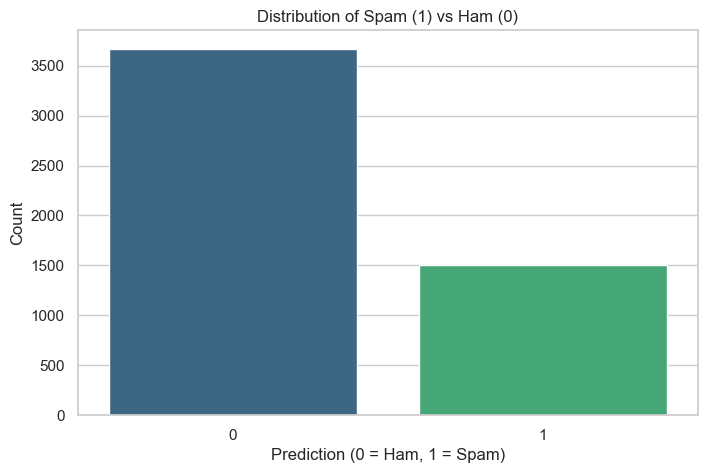

In [4]:
# Target column distribution
prediction_counts = df['Prediction'].value_counts()
print("Distribution of Prediction column:")
print(prediction_counts)

# Visualize the balance of Spam vs Ham
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Prediction', hue='Prediction', palette='viridis', legend=False)
plt.title('Distribution of Spam (1) vs Ham (0)')
plt.xlabel('Prediction (0 = Ham, 1 = Spam)')
plt.ylabel('Count')
plt.show()

## 5. Most Common Words
Calculating and visualizing the top 10 most common words overall across the dataset.

Top 10 most common words:
e    438561
t    312791
a    287136
o    284970
n    248777
i    237177
r    234874
s    216251
l    160317
c    154690
dtype: int64


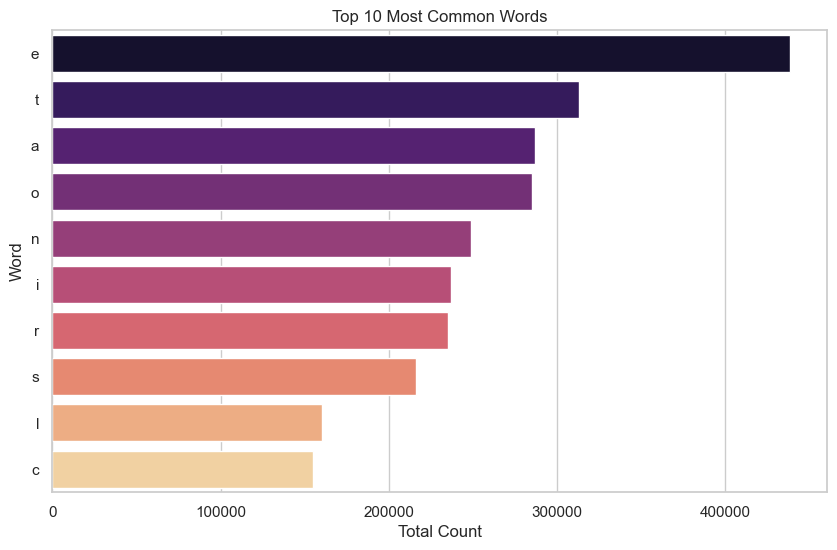

In [5]:
# All columns except 'Prediction' represent word counts
word_columns = df.columns.drop('Prediction')

# Sum the counts for each word across all emails
word_counts = df[word_columns].sum().sort_values(ascending=False)

# Get the top 10 most common words
top_10_words = word_counts.head(10)
print("Top 10 most common words:")
print(top_10_words)

# Visualize the top 10 words
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_words.values, y=top_10_words.index, hue=top_10_words.index, palette='magma', legend=False)
plt.title('Top 10 Most Common Words')
plt.xlabel('Total Count')
plt.ylabel('Word')
plt.show()

## 6. Data Splitting
Separating the features (`X`) from the target variable (`y`) and splitting into a 75/25 train-test split.

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Prediction', axis=1)
y = df['Prediction']

# Train-test split (75/25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (3879, 3000)
Testing set shape: (1293, 3000)


## 7. Model Training and Evaluation
Training `LogisticRegression` and `MultinomialNB` classifiers, and evaluating their performance.

--- Training Logistic Regression ---


Accuracy: 0.9714
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       913
           1       0.94      0.96      0.95       380

    accuracy                           0.97      1293
   macro avg       0.96      0.97      0.97      1293
weighted avg       0.97      0.97      0.97      1293



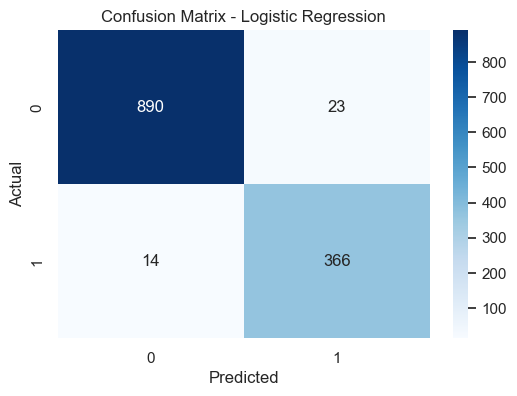



--- Training Multinomial Naive Bayes ---


Accuracy: 0.9466
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       913
           1       0.88      0.95      0.91       380

    accuracy                           0.95      1293
   macro avg       0.93      0.95      0.94      1293
weighted avg       0.95      0.95      0.95      1293



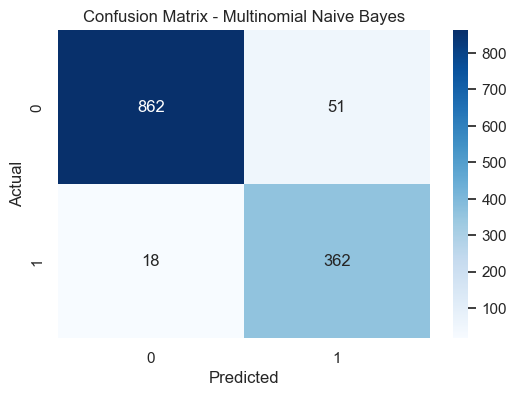

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models
log_reg = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

models = {
    'Logistic Regression': log_reg,
    'Multinomial Naive Bayes': nb_model
}

results = {}

for name, model in models.items():
    print(f"--- Training {name} ---")
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'y_pred': y_pred
    }
    
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("\n")


## 8. Exporting the Best Model
Saving the best performing model and the list of feature column names for later use in the UI.

In [8]:
import joblib
import pickle

# Pick the model with the highest accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_model_name]['model']

print(f"Best model selected: {best_model_name} with test accuracy {results[best_model_name]['accuracy']:.4f}")

# Save the trained model object
joblib.dump(best_model, 'spam_model.pkl')
print("Saved model as 'spam_model.pkl'")

# Save the list of training feature column names
features_list = list(X.columns)
with open('model_features.pkl', 'wb') as f:
    pickle.dump(features_list, f)
print("Saved feature names as 'model_features.pkl'")


Best model selected: Logistic Regression with test accuracy 0.9714
Saved model as 'spam_model.pkl'
Saved feature names as 'model_features.pkl'
